# 07 — Multi-Agent Concept Demo
**Day 6.** Goal: demonstrate the multi-agent architecture with working code — five agents, each
with a defined input/output contract, wired into one pipeline, every decision logged in plain
language.

**Agent responsibilities:**
| Agent | Responsibility | Data basis |
|---|---|---|
| Forecast Agent | Next-day generation + demand forecast | Real (Day 3/4 models) |
| Optimization Agent | Battery charge/discharge suggestion | Real forecast + MOCKED battery |
| Maintenance Agent | Highest-risk turbine flag | Real (alarm/maintenance history, 50 turbines) |
| Grid Agent | Overload/curtailment check | Real forecast vs. ASSUMED capacity |
| Carbon Agent | Avoided CO2 + renewable utilization | Real forecast vs. ASSUMED emission factor |

Every agent returns the same `AgentResult` shape (`src/agents/base.py`) — swap any one for a
trained model later without touching the pipeline or the other agents.

In [1]:
import sys, os
from pathlib import Path
import json
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from src.utils.config_loader import load_config
from src.agents.pipeline import run_pipeline, log_pipeline_run, print_pipeline_summary

cfg = load_config()


## 1. Run the full pipeline
Forecast Agent runs first (everything else depends on its output); Maintenance Agent runs independently; Optimization, Grid, and Carbon Agents all consume the Forecast Agent's output.

In [2]:
results = run_pipeline(cfg)
print_pipeline_summary(results)


[Forecast Agent]
  Forecasting 16,054 kWh generation for the day after 2025-12-31 (model test MAE: 992 kWh). Today's actual generation was 19,734 kWh, up 17.1% vs. the trailing 7-day average. 

[Maintenance Agent]
  WTG_026 has the highest risk score (315.4) over the last 90 days: 53 failures, 1764h downtime, most affected component 'Gearbox'. Recommendation: Schedule inspection. [Rule-based risk score from real alarm/maintenance data, not a trained failure model.]

[Optimization Agent]
  No demand forecast available -- Optimization Agent has nothing to balance against, holding all batteries.

[Grid Agent]
  Tomorrow's forecast (16,054 kWh) vs. assumed export capacity (22,000 kWh): within capacity, headroom 5,946 kWh. No corrective action needed -- forecast is comfortably within assumed export capacity. [Capacity figure is an assumed planning constraint, not a measured grid limit.]

[Carbon Agent]
  Tomorrow's 16,054 kWh forecast avoids an estimated 13,164 kg CO2 (~13.16 t), using an a

## 2. Inspect each agent's structured output
The explanation strings above are for humans (the demo/dashboard); the structured `output` dict is what a real downstream system or the copilot would consume.

In [3]:
for r in results:
    print(f"--- {r.agent_name} ---")
    print(json.dumps(r.output, indent=2, default=str)[:600])
    print()


--- Forecast Agent ---
{
  "anchor_date": "2025-12-31",
  "turbine_id": "WTG_001",
  "actual_generation_today_kwh": 19733.7,
  "actual_power_loss_today_kwh": 2528.5,
  "alarm_minutes_today": 20,
  "mean_wind_speed_today_mps": 7.85,
  "seasonal_avg_wind_speed_mps": 7.51,
  "wind_vs_seasonal_pct": 4.5,
  "trailing_7d_avg_generation_kwh": 16846.1,
  "generation_vs_trailing_avg_pct": 17.1,
  "next_day_generation_forecast_kwh": 16054.1,
  "next_day_demand_forecast_kwh": null,
  "demand_is_synthetic_proxy": true,
  "model_test_mae_kwh": 991.6051401654413
}

--- Maintenance Agent ---
{
  "turbine_id": "WTG_026",
  "risk_score": 315.4,
  "n_failures_90d": 53,
  "total_downtime_hours_90d": 1763.7,
  "most_common_component": "Gearbox",
  "recommended_action": "Schedule inspection",
  "top5_ranking": [
    {
      "turbine_id": "WTG_026",
      "n_failures": 53,
      "total_downtime_hours": 1763.7,
      "max_severity_score": 4,
      "last_failure_date": "2025-12-30 12:00:00",
      "most_commo

## 3. Log the run
Appends one JSON line per agent to `logs/agent_decisions_<date>.jsonl` — this is the explainability record the work plan calls for, and what Day 8's dashboard will read to show an agent activity feed.

In [4]:
log_path = log_pipeline_run(results, cfg)
print("Logged to:", log_path)

# show the log file's contents as a clean table
log_df = pd.DataFrame([json.loads(line) for line in open(log_path)])
log_df[["timestamp", "agent", "explanation"]]


Logged to: logs\agent_decisions_20260813.jsonl


,timestamp,agent,explanation
0,2026-08-13T12:53:27.724808+00:00,Forecast Agent,"Forecasting 16,054 kWh generation for the day ..."
1,2026-08-13T12:53:28.751114+00:00,Maintenance Agent,WTG_026 has the highest risk score (315.4) ove...
2,2026-08-13T12:53:28.752603+00:00,Optimization Agent,No demand forecast available -- Optimization A...
3,2026-08-13T12:53:28.752603+00:00,Grid Agent,"Tomorrow's forecast (16,054 kWh) vs. assumed e..."
4,2026-08-13T12:53:28.752603+00:00,Carbon Agent,"Tomorrow's 16,054 kWh forecast avoids an estim..."


## 4. Agent collaboration diagram
For the final presentation — how the agents connect, and what's real vs. mocked/assumed.

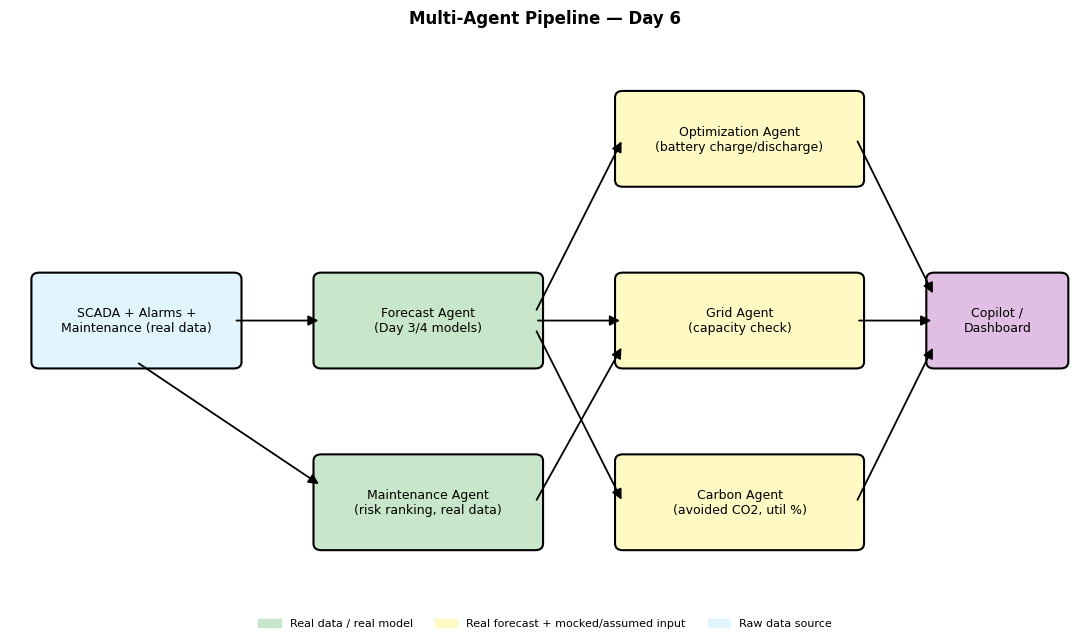

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.set_xlim(0, 11)
ax.set_ylim(0, 7)
ax.axis("off")

def box(x, y, w, h, label, color):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.08",
                                 linewidth=1.5, edgecolor="black", facecolor=color))
    ax.text(x + w/2, y + h/2, label, ha="center", va="center", fontsize=9, wrap=True)

def arrow(x1, y1, x2, y2):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="-|>", mutation_scale=15,
                                  linewidth=1.3, color="black"))

real_color = "#c8e6c9"     # green -- real data
mixed_color = "#fff9c4"    # yellow -- real forecast + assumption/mock
mock_color = "#ffcdd2"     # red -- mocked

box(0.3, 3, 2, 1, "SCADA + Alarms +\nMaintenance (real data)", "#e1f5fe")
box(3.2, 3, 2.2, 1, "Forecast Agent\n(Day 3/4 models)", real_color)

box(6.3, 5.2, 2.4, 1, "Optimization Agent\n(battery charge/discharge)", mixed_color)
box(6.3, 3, 2.4, 1, "Grid Agent\n(capacity check)", mixed_color)
box(6.3, 0.8, 2.4, 1, "Carbon Agent\n(avoided CO2, util %)", mixed_color)

box(3.2, 0.8, 2.2, 1, "Maintenance Agent\n(risk ranking, real data)", real_color)

box(9.5, 3, 1.3, 1, "Copilot /\nDashboard", "#e1bee4")

arrow(1.3, 3.0, 3.2, 1.5)   # raw data -> Maintenance Agent (alarms/maintenance history)
arrow(2.3, 3.5, 3.2, 3.5)   # raw data -> Forecast Agent (SCADA)
arrow(5.4, 3.6, 6.3, 5.7)   # Forecast -> Optimization
arrow(5.4, 3.5, 6.3, 3.5)   # Forecast -> Grid
arrow(5.4, 3.4, 6.3, 1.3)   # Forecast -> Carbon
arrow(5.4, 1.3, 6.3, 3.2)   # Maintenance -> Grid (shares the same corridor toward the dashboard)
arrow(8.7, 5.7, 9.5, 3.8)   # Optimization -> Copilot/Dashboard
arrow(8.7, 3.5, 9.5, 3.5)   # Grid -> Copilot/Dashboard
arrow(8.7, 1.3, 9.5, 3.2)   # Carbon -> Copilot/Dashboard

legend_patches = [
    mpatches.Patch(color=real_color, label="Real data / real model"),
    mpatches.Patch(color=mixed_color, label="Real forecast + mocked/assumed input"),
    mpatches.Patch(color="#e1f5fe", label="Raw data source"),
]
ax.legend(handles=legend_patches, loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=3, fontsize=8, frameon=False)
ax.set_title("Multi-Agent Pipeline — Day 6", fontsize=12, fontweight="bold")

fig.tight_layout()
fig.savefig(PROJECT_ROOT / "reports/figures/day6_agent_architecture.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Checkpoint — Day 6 complete

- Five agents implemented with a shared `AgentResult` contract (`src/agents/base.py`).
- Pipeline wired: Forecast → {Optimization, Grid, Carbon}, Maintenance running independently.
- Every decision logged in plain language to `logs/agent_decisions_<date>.jsonl`.
- Architecture diagram saved to `reports/figures/day6_agent_architecture.png` for the final deck —
  color-coded so the audience can see exactly what's real data vs. an assumption/mock, matching
  the honesty theme carried through every prior day.

**What's real vs. not, stated plainly for the demo script:**
- Forecast + Maintenance: real data, real models/rules.
- Optimization, Grid, Carbon: real forecast numbers feeding rule-based logic with clearly-labeled
  mocked (battery) or assumed (grid capacity, emission factor) inputs.

Next: Day 7 — replace the Optimization Agent's single-step rule with a proper multi-period battery
scheduling optimization (PuLP), and extend the Grid Agent with the three required scenario
simulations (overload, outage, voltage instability).